## Exploratory Data Analysis
* an approach to analyze data in order to summarize main characteristics of the data
    * to gain better understanding of the data set.
    * uncover relationships between different variables.
    * extract important variables for the problem we trying to solve/answer.
    
### What are the characteristics  that have the most impact on the car price?

In [1]:
import pandas as pd
import numpy as np

file_name = "clean_df_Auto.csv"
df = pd.read_csv(file_name, header=0, index_col=0)
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,21,27,13495.0,11.190476,8.703704,Low,False,True,True,False
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,21,27,16500.0,11.190476,8.703704,Low,False,True,True,False
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,19,26,16500.0,12.368421,9.038462,Medium,False,True,True,False
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,24,30,13950.0,9.791667,7.833333,Low,False,True,True,False
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,18,22,17450.0,13.055556,10.681818,Low,False,True,True,False


### Descriptive Statistics
* Description statistical analysis helps to describe basic features of a dataset and obtain short summary about the sample and measures of the data.
* use the describe() method in Pandas to give a summary of basic statistics for all numerical variables, specifically continuous data. e.g. mean, max, min, std, any NaN values are skipped.
* for Categorical data or Discrete value data, they can be summarized using the value_counts() method.
* Box Plots are great for visualization of numeric data since it can demonstrate the different distribution of the data, e.g. the Median, Upper/Lower(75/25%) Quartile, Upper/Lower Extreme(+-1.5%), Max/Min values, and Outliers.
* Scatter Plots are usually used for visualizing Continuous Data. It shows the relationship between two variables:
    * Predictor/Independent variables on x-axis.
    * Target/Dependent variables on y-axis is the variable we are trying to predict.
* Grouping Data helps us to see if there is any relationship between variables.
    * we can use df.groupby() method in Pandas for grouping data. Use this method for:
        * Categorical variables, e.g. 'drive-wheels', 'body-style'
        * Grouping data into Categories
        * can group by Single or Multiple variables
* Pivot Table can be generated from the above Grouped DataFrame.
    * we used the DataFrame Pivot() method.
    * 1 variable is displayed along the columns, and the other is displayed along the rows.
* Heatmap Plot can help to visialize Pivot Table.
    * Useful for plotting target variable against multiple variables.
    * Color intensity is used to represent the different values of the data.

In [2]:
# Analyzing Individual Featuer Patterns using Visualization

import matplotlib.pyplot as plt
import seaborn as sns

df.dtypes

symboling              int64
normalized-losses      int64
make                     str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
highway-L/100km      float64
horsepower-binned        str
fuel-type-diesel        bool
fuel-type-gas           bool
aspiration-std          bool
aspiration-turbo        bool
dtype: object

In [3]:
df['peak-rpm'].dtype

dtype('float64')

In [4]:
# select only numeric columns for correlation
df_num = df.select_dtypes(include=['float64','int64'])
df_num.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008153,-0.182196,0.075810,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.029807
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055045,-0.114713,0.217300,0.239543,-0.225016,-0.181877,0.133999,0.238567,0.181189
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158018,0.250313,0.371178,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.577576
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.123952,0.159733,0.579795,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.707108
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188822,0.189867,0.615056,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.736728
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.060663,0.259737,-0.087001,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.084301
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167438,0.156433,0.757981,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.836921
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.205928,0.028889,0.822668,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.783465
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566903,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.559112
stroke,-0.008153,0.055045,0.158018,0.123952,0.188822,-0.060663,0.167438,0.205928,-0.055390,1.000000,0.187871,0.098128,-0.063561,-0.033956,-0.034636,0.082269,0.036133,0.047089


In [5]:
# correlation between selected columns
df[['bore','stroke','compression-ratio','horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566903
stroke,-0.055390,1.000000,0.187871,0.098128
compression-ratio,0.001263,0.187871,1.000000,-0.214489
horsepower,0.566903,0.098128,-0.214489,1.000000


(0.0, 53514.120875997105)

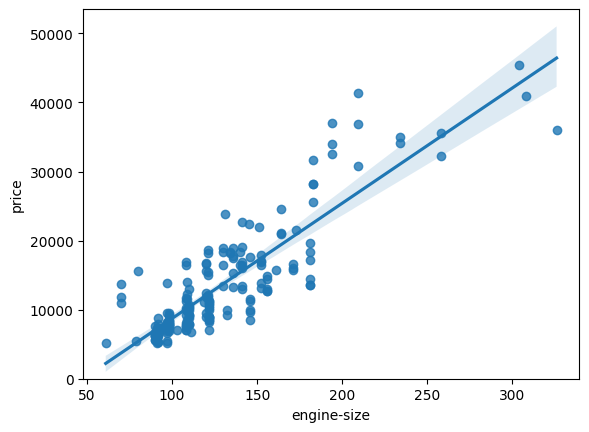

In [6]:
# Continuous Numerical variables with scatterplot
sns.regplot(x='engine-size',y='price', data=df)
plt.ylim(0,)


In [7]:
# correlation between engine-size and price
df[['engine-size','price']].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


<Axes: xlabel='highway-mpg', ylabel='price'>

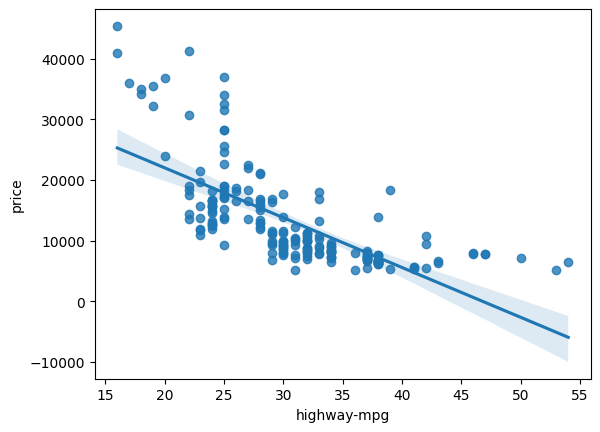

In [8]:
# scatterplot between highway-mpg and price - negative correlation
sns.regplot(x='highway-mpg',y='price',data=df)

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


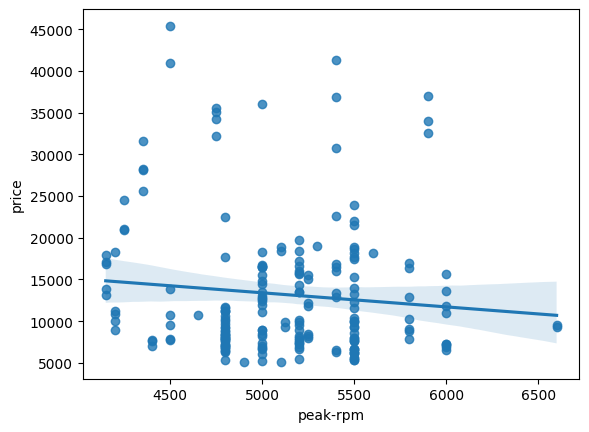

In [9]:
# scatterplot between peak-rpm and price  - weak linear relationship
sns.regplot(x='peak-rpm',y='price',data=df)
df[['peak-rpm','price']].corr()

,stroke,price
stroke,1.000000,0.082269
price,0.082269,1.000000


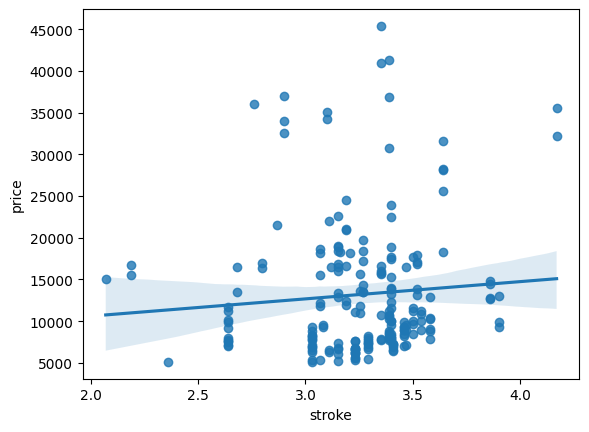

In [10]:
# scatterplot between stroke and price  - weak positive relationship
sns.regplot(x='stroke',y='price',data=df)
df[['stroke','price']].corr()

### Categorical Variables
* for categorical values, we can use the value_counts() method.
* Box plots are a great way to visualize numeric data, as it shows the median, upper and lower quartile, and inter quartile range.
* Box plots also shows the outliers in the data set.
* Box plots make it easy to compare between groups.

<Axes: xlabel='body-style', ylabel='price'>

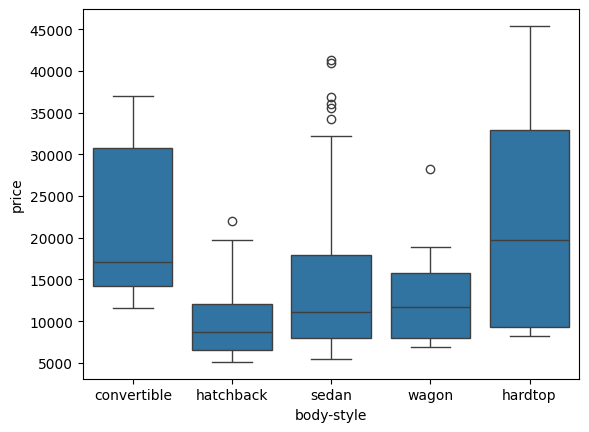

In [11]:

# As shown there a significant overlap in the distribution, so body-style is not a good predictor of price.
sns.boxplot(x='body-style',y='price', data=df)

<Axes: xlabel='engine-location', ylabel='price'>

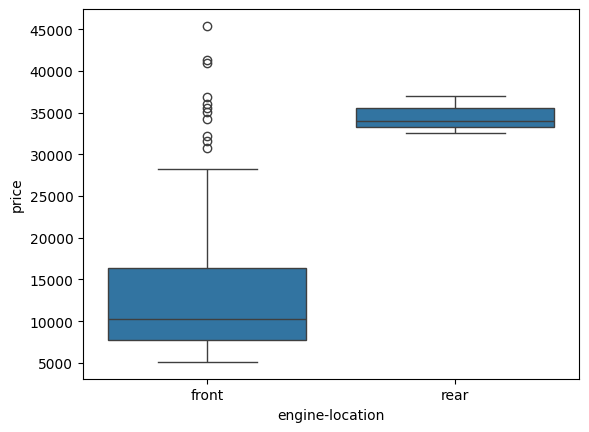

In [12]:
# engine-location vs price  - a good predictor of price
sns.boxplot(x='engine-location',y='price', data=df)

<Axes: xlabel='drive-wheels', ylabel='price'>

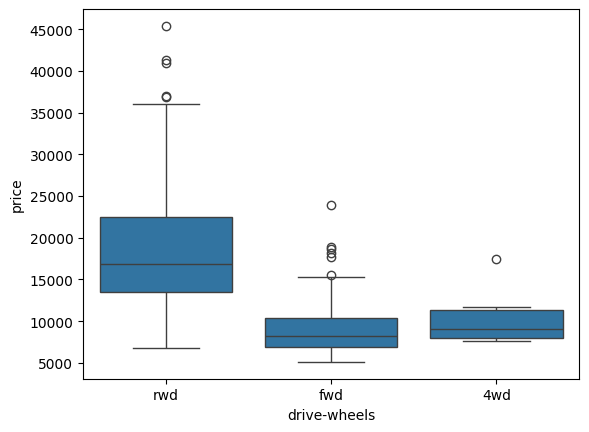

In [13]:
# drive-wheels vs price - potentially a good predictor of price
sns.boxplot(x='drive-wheels',y='price', data=df)

In [14]:
# Descriptive Statistical Analysis

df.describe() # does not include object and string types

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,0.899108,2555.666667,126.875622,3.330692,3.256874,10.164279,103.402985,5117.665368,25.179104,30.686567,13207.129353,9.944145,8.044957
std,1.254802,31.99625,6.066366,0.059213,0.029187,0.040933,517.296727,41.546834,0.268072,0.316048,4.004965,37.365650,478.113805,6.423220,6.815150,7947.066342,2.534599,1.840739
min,-2.000000,65.00000,86.600000,0.678039,0.837500,0.799331,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,4.351852
25%,0.000000,101.00000,94.500000,0.801538,0.890278,0.869565,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,6.911765
50%,1.000000,122.00000,97.000000,0.832292,0.909722,0.904682,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,7.833333
75%,2.000000,137.00000,102.400000,0.881788,0.925000,0.928094,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,9.400000
max,3.000000,256.00000,120.900000,1.000000,1.000000,1.000000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,14.687500


In [15]:
df.describe(include=['object','string'])

,make,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201
unique,22,2,5,3,2,6,7,8,3
top,toyota,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,115,94,118,198,145,157,92,153


In [16]:
# value counts
df[['drive-wheels']].value_counts() # returns a series
df[['drive-wheels']].value_counts().to_frame() # convert the series to dataframe


,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [17]:
# Value Counts

# drive-wheels
df_drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
df_drive_wheels_counts.reset_index(inplace=True)
df_drive_wheels_counts = df_drive_wheels_counts.rename(columns={'drive-wheels':'value_counts'})
df_drive_wheels_counts.index.name = 'drive-wheels'
df_drive_wheels_counts

,value_counts,count
drive-wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


In [18]:
# engine-location
df_engine_location_counts = df['engine-location'].value_counts().to_frame()
df_engine_location_counts.reset_index(inplace=True)
df_engine_location_counts = df_engine_location_counts.rename(columns={'engine-location':'value_counts'})
df_engine_location_counts.index.name = 'engine-location'
df_engine_location_counts

,value_counts,count
engine-location,,
0,front,198
1,rear,3


### GroupBy

It would be nice if we could group all the data by the different types of drive wheels and compare the results of these different drive wheels against each other. 

* The groupby method is used on categorical variables.
* it groups the data into subsets according to the different categories of that variable.
* you can group by a single variable, or you can group by multiple variables by passing in multiple variable names.

In [19]:
# Grouping

# If we want to know on average which type of drive wheel is most valuable
df_group = df[['drive-wheels','body-style','price']]
df_groupby_drive_wheels = df_group.groupby(['drive-wheels'], as_index=False).agg({'price':'mean'})
df_groupby_drive_wheels
# from the result, real-wheel drive vehicles are on average the most expensive.

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


In [20]:
# grouping by multiple columns value
df_groupby_multi_col = df_group.groupby(['drive-wheels','body-style'], as_index=False).mean()
print(df_groupby_multi_col)

df_pivot_multi_col = df_groupby_multi_col.pivot(index='drive-wheels',columns='body-style').fillna(0) # better visualization in pivot table
df_pivot_multi_col


   drive-wheels   body-style         price
0           4wd    hatchback   7603.000000
1           4wd        sedan  12647.333333
2           4wd        wagon   9095.750000
3           fwd  convertible  11595.000000
4           fwd      hardtop   8249.000000
5           fwd    hatchback   8396.387755
6           fwd        sedan   9811.800000
7           fwd        wagon   9997.333333
8           rwd  convertible  23949.600000
9           rwd      hardtop  24202.714286
10          rwd    hatchback  14337.777778
11          rwd        sedan  21711.833333
12          rwd        wagon  16994.222222


price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [21]:
# find the average price of each car based on body-style
df_groupby_body_style = df_group.groupby(['body-style'],as_index=False).agg({'price':'mean'})
df_groupby_body_style.sort_values('price')


,body-style,price
2,hatchback,9957.441176
4,wagon,12371.960000
3,sedan,14459.755319
0,convertible,21890.500000
1,hardtop,22208.500000


### Visualization
* matplotlib.pyplot
    * most of the plots that are of interest to us are contained in the pyplot sub folder of the matplotlib package.
    * plt.plot(x,y) for Line Plot.
    * plt.scatter(x,y) for Scatter Plot.
    * plt.hist(x,bins) for Histogram. For better clarity set the edgecolor.
    * plt.bar(x,height) for Bar Plot. 
    * plt.pcolor(C) for setting the color set for Pseudo Color Plot which displays matrix data as an array of colored cells.

* seaborn
    * sns.regplot() for Regression Plot.
    * sns.residplot() for Residual Plot is used to display the quality of polynomial regression.
    * sns.kkeplot() for Kernel Density Estimate Plot is a graph that creates a probability distribution curve for the data based on likelihood of occurrence.
    * sns.distplot() for Distribution Plot combine the histogram and the KDE plots.
    

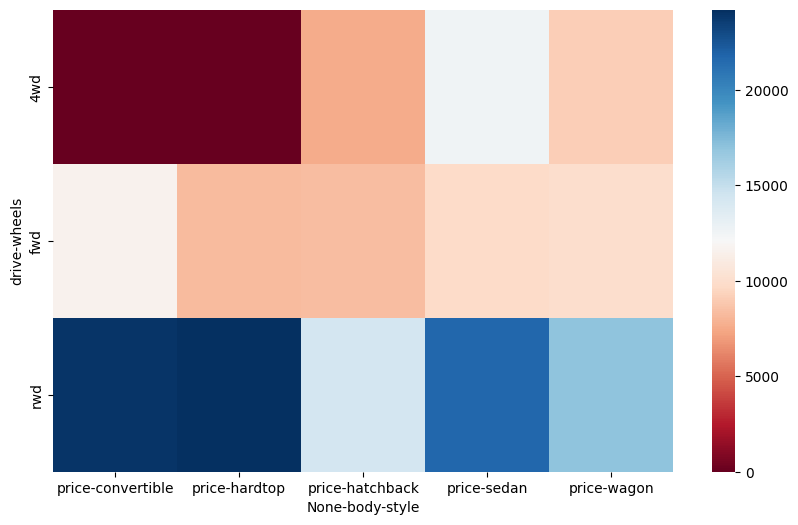

In [22]:
# heatmap - body-style vs price
plt.figure(figsize=(10,6))
hm = sns.heatmap(df_pivot_multi_col, cmap='RdBu')
plt.show()

### Correlation
* Correlation is a statistical metric for measuring to what extent different variables are interdependent. 
* Correlation doesn't imply causation. Umbrella and rain are correlated, but insufficient information to say if the umbrella caused the rain or vice versa.
* In data science, we usually deal more with correlation.


In [23]:
# What are the main characteristics which have the most impact on the car price?
# To answer this question, we need to look at correlation of all the variables with the price.

df.select_dtypes(include=['number']).corr()  # correlation only works with numeric values

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008153,-0.182196,0.075810,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.029807
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055045,-0.114713,0.217300,0.239543,-0.225016,-0.181877,0.133999,0.238567,0.181189
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158018,0.250313,0.371178,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.577576
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.123952,0.159733,0.579795,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.707108
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188822,0.189867,0.615056,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.736728
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.060663,0.259737,-0.087001,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.084301
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167438,0.156433,0.757981,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.836921
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.205928,0.028889,0.822668,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.783465
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566903,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.559112
stroke,-0.008153,0.055045,0.158018,0.123952,0.188822,-0.060663,0.167438,0.205928,-0.055390,1.000000,0.187871,0.098128,-0.063561,-0.033956,-0.034636,0.082269,0.036133,0.047089


### Pearson Correlation
* Pearson Correlation Method measures the strength of the correlation between continuous numerical variables.
* The method will generate two values: The Correlation Coefficient, and P-value.
* The correlation coefficient: 
    - a value close to 1 implies a large positive correlation.
    - a value close to -1 implies a large negative correlation. 
    - a value close to zero implies no correlation between the variables.
* The P-value: 
    - tell us how certain (statistically significant) we are about the correlation between the two variables. 
    - a value less than 0.001 gives us a strong certainty about the correlation coefficient.
    - a value between 0.001 and 0.05 gives us moderate certainty.
    - a value between 0.05 and 0.1 will give us a weak certainty. 
    - a p-value larger than 0.1 will give us no certainty of correlation at all. 

We can say that there is a strong correlation when the correlation coefficient is close to 1 or -1, and the p-value is less than 0.001 (99.999% confidence).


In [24]:

from scipy import stats

In [25]:
pc = stats.pearsonr(df['wheel-base'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between wheel-base and price is statistically significant, although the linear relationship is not very strong.

Pearson Correlation: 0.584641822265508
P-value 8.076488270732947e-20


In [26]:
pc = stats.pearsonr(df['horsepower'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between horsepower and price is statistically significant, and the linear relationship is quite strong.

Pearson Correlation: 0.8096068016571054
P-value 6.27353627065033e-48


In [27]:
pc = stats.pearsonr(df['length'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between length and price is statistically significant, and the linear relationship is morderately strong.

Pearson Correlation: 0.6906283804483639
P-value 8.016477466159241e-30


In [28]:
pc = stats.pearsonr(df['width'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between width and price is statistically significant, and the linear relationship is strong.

Pearson Correlation: 0.7512653440522675
P-value 9.200335510480637e-38


In [29]:
pc = stats.pearsonr(df['curb-weight'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between curb-weight and price is statistically significant, and the linear relationship is quite strong.

Pearson Correlation: 0.8344145257702844
P-value 2.1895772388939584e-53


In [30]:
pc = stats.pearsonr(df['engine-size'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between engine-size and price is statistically significant, and the linear relationship is quite strong.

Pearson Correlation: 0.8723351674455184
P-value 9.265491622198827e-64


In [31]:
pc = stats.pearsonr(df['bore'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between bore and price is statistically significant, and the linear relationship is morderately strong.

Pearson Correlation: 0.5431553832626603
P-value 8.049189483935246e-17


In [32]:
pc = stats.pearsonr(df['city-mpg'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between city-mpg and price is statistically significant, and the linear relationship is negatively morderately strong.

Pearson Correlation: -0.686571006784468
P-value 2.3211320655674997e-29


In [33]:
pc = stats.pearsonr(df['highway-mpg'],df['price'])
print(f"Pearson Correlation: {pc.statistic}")
print(f"P-value {pc.pvalue}")

# Since the p-value is < 0.001, the correlation between highway-mpg and price is statistically significant, and the linear relationship is negatively morderately strong.

Pearson Correlation: -0.7046922650589531
P-value 1.7495471144475605e-31


### Chi-Square Test for Categorical Variables
    * this is a statistical test method to determine if there is a significant association between two categorical variables.
    * it is a non-parametric statistical method that evaluates whether the observed frequencies in each category differ significantly from the expected frequencies.

#### Null Hypothesis and Alternative Hypothesis
    * the Chi-Square Test involves formulating two hypotheses:
        * Null Hypotheses (H0) : Assumes that there is no association between the categorical variables, implying that any observed differences are due to random chance.
        * Alternative Hypothesis (H1) : Assumes that there is a significant association between the variables, indicating that the observed differences are not due to chance alone.

#### Chi-Square Distribution Table
    * provides critical values that vary by degrees of freedom and the significance level (alpha). These values indicate the threshold beyond which the test statistic would be considered statistically significant.



In [34]:
# Chi-Square Test

from scipy.stats import chi2_contingency

# Create the contingency table
data = [[20, 30],  # Male: [Like, Dislike]
        [25, 25]]  # Female: [Like, Dislike]

# Create a DataFrame for clarity
df = pd.DataFrame(data, columns=["Like", "Dislike"], index=["Male", "Female"])

# Perform the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(df)

# Display results
print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("Expected Frequencies:\n", expected)

Chi-square Statistic: 0.6464646464646464
Degrees of Freedom: 1
P-value: 0.4213795037428696
Expected Frequencies:
 [[22.5 27.5]
 [22.5 27.5]]


### Conclusion - Important variables

We now have a better idea of what our data looks like and which variables are important to take into account when predicting the car price. 

* We have narrowed it down to the following variables:
    * Continuous numerical variables:
        - Length
        - Width
        - Curb-weight
        - Engine-size
        - Horsepower
        - City-mpg
        - Highway-mpg
        - Wheel-base
        - Bore

    * Categorical variables:
        - Drive-wheels

As we now move into building machine learning models to automate our analysis, feeding the model with variables that meaningfully affect our target variable will improve our model's prediction performance.
